# 04 - Social Network Analysis

This notebook builds a Yelp user-user friendship graph for active New Orleans reviewers and creates user-level network features for forecasting.

Friendship links are static in the Yelp dataset, so these features are interpreted as social context rather than causal influence.

## Design Choices

- Active reviewer: at least 5 reviews in the New Orleans subset.
- Nodes: active New Orleans reviewers.
- Edges: Yelp friendships where both users are active New Orleans reviewers.
- Features: degree, PageRank, component size, active flag, and community label where feasible.
- Full betweenness centrality is avoided because it is too expensive for this graph size.

In [1]:
from pathlib import Path
import json
from collections import Counter

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

INTERIM_DIR = PROJECT_ROOT / "data" / "interim" / "new_orleans"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "new_orleans"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures" / "sna"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

REVIEWS_PATH = INTERIM_DIR / "reviews.jsonl"
USERS_PATH = INTERIM_DIR / "users.jsonl"
USER_NETWORK_FEATURES_PATH = PROCESSED_DIR / "user_network_features.csv"
GRAPH_SUMMARY_PATH = PROCESSED_DIR / "social_graph_summary.json"
ACTIVE_REVIEW_THRESHOLD = 5

plt.rcParams.update({"figure.figsize": (10, 5), "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False})
print(PROJECT_ROOT)

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp


In [2]:
def iter_jsonl(path):
    with path.open("r", encoding="utf-8") as file:
        for line_number, line in enumerate(file, start=1):
            try:
                yield json.loads(line)
            except json.JSONDecodeError as exc:
                raise ValueError(f"Invalid JSON in {path} at line {line_number}") from exc

In [3]:
user_review_counts = Counter()
for record in iter_jsonl(REVIEWS_PATH):
    user_review_counts[record["user_id"]] += 1

all_reviewing_user_ids = set(user_review_counts)
active_user_ids = {uid for uid, count in user_review_counts.items() if count >= ACTIVE_REVIEW_THRESHOLD}

print(f"Reviewing users: {len(all_reviewing_user_ids):,}")
print(f"Active users with at least {ACTIVE_REVIEW_THRESHOLD} reviews: {len(active_user_ids):,}")

Reviewing users: 245,421
Active users with at least 5 reviews: 26,598


In [4]:
G = nx.Graph()
G.add_nodes_from(active_user_ids)
matched_profiles = 0
active_profiles = 0

for record in iter_jsonl(USERS_PATH):
    uid = record["user_id"]
    if uid not in all_reviewing_user_ids:
        continue
    matched_profiles += 1
    if uid not in active_user_ids:
        continue
    active_profiles += 1
    friends = record.get("friends") or ""
    if friends == "None":
        continue
    for fid in friends.replace(", ", ",").split(","):
        fid = fid.strip()
        if fid and fid in active_user_ids and uid < fid:
            G.add_edge(uid, fid)

print(f"Matched user profiles: {matched_profiles:,}")
print(f"Active user profiles: {active_profiles:,}")
print(f"Graph nodes: {G.number_of_nodes():,}")
print(f"Graph edges: {G.number_of_edges():,}")

Matched user profiles: 245,419
Active user profiles: 26,598
Graph nodes: 26,598
Graph edges: 116,558


In [5]:
degree = dict(G.degree())
components = sorted(nx.connected_components(G), key=len, reverse=True)
component_id_by_user = {}
component_size_by_user = {}
for cid, nodes in enumerate(components):
    for node in nodes:
        component_id_by_user[node] = cid
        component_size_by_user[node] = len(nodes)

pagerank = nx.pagerank(G, alpha=0.85, max_iter=100, tol=1e-6) if G.number_of_edges() else {node: 0.0 for node in G.nodes}

community_by_user = {node: -1 for node in G.nodes}
community_method = "not_computed"
if components and len(components[0]) >= 3:
    largest = G.subgraph(components[0]).copy()
    try:
        communities = nx.algorithms.community.louvain_communities(largest, seed=42)
        community_method = "louvain_largest_component"
        for community_id, nodes in enumerate(communities):
            for node in nodes:
                community_by_user[node] = community_id
    except Exception as exc:
        community_method = f"not_computed: {type(exc).__name__}: {exc}"

print(f"Connected components: {len(components):,}")
print(f"Largest component size: {len(components[0]) if components else 0:,}")
print(f"Isolated active users: {sum(1 for _, d in G.degree() if d == 0):,}")
print(f"Community method: {community_method}")

Connected components: 11,508
Largest component size: 14,965
Isolated active users: 11,387
Community method: louvain_largest_component


In [6]:
rows = []
for uid in all_reviewing_user_ids:
    rows.append({
        "user_id": uid,
        "subset_review_count": user_review_counts[uid],
        "active_reviewer": int(uid in active_user_ids),
        "friend_degree": degree.get(uid, 0),
        "pagerank": pagerank.get(uid, 0.0),
        "component_id": component_id_by_user.get(uid, -1),
        "component_size": component_size_by_user.get(uid, 0),
        "community_id": community_by_user.get(uid, -1),
    })

user_network_features = pd.DataFrame(rows)
user_network_features.to_csv(USER_NETWORK_FEATURES_PATH, index=False)

summary = {
    "active_review_threshold": ACTIVE_REVIEW_THRESHOLD,
    "reviewing_users": len(all_reviewing_user_ids),
    "matched_user_profiles": matched_profiles,
    "active_users": len(active_user_ids),
    "graph_nodes": G.number_of_nodes(),
    "graph_edges": G.number_of_edges(),
    "connected_components": len(components),
    "largest_component_size": len(components[0]) if components else 0,
    "isolated_active_users": sum(1 for _, d in G.degree() if d == 0),
    "community_method": community_method,
    "communities_assigned": len(set(v for v in community_by_user.values() if v >= 0)),
    "output": str(USER_NETWORK_FEATURES_PATH),
}
with GRAPH_SUMMARY_PATH.open("w", encoding="utf-8") as file:
    json.dump(summary, file, indent=2)
    file.write("\n")
summary

{'active_review_threshold': 5,
 'reviewing_users': 245421,
 'matched_user_profiles': 245419,
 'active_users': 26598,
 'graph_nodes': 26598,
 'graph_edges': 116558,
 'connected_components': 11508,
 'largest_component_size': 14965,
 'isolated_active_users': 11387,
 'community_method': 'louvain_largest_component',
 'communities_assigned': 24,
 'output': 'C:\\Users\\mehdi\\OneDrive\\Documents\\community-forecasting-yelp\\data\\processed\\new_orleans\\user_network_features.csv'}

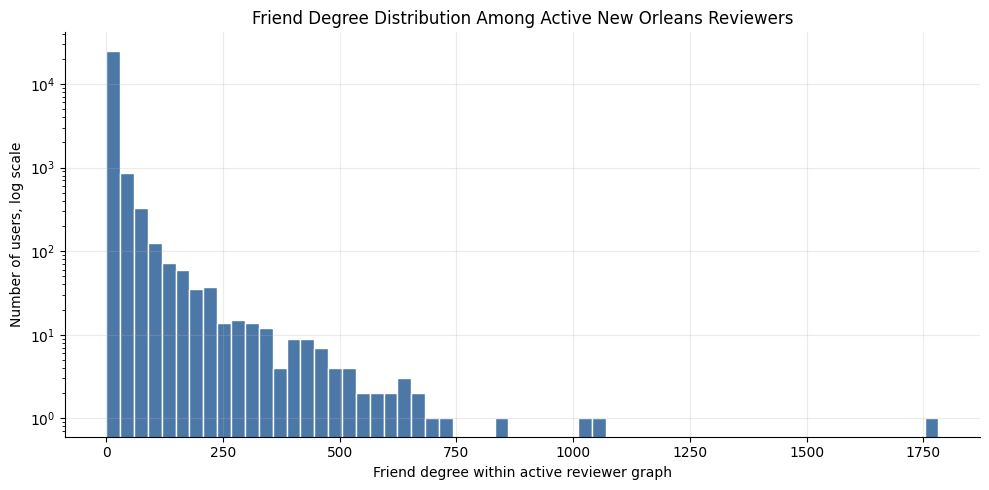

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\sna\active_user_degree_distribution.png


In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(list(degree.values()), bins=60, color="#4C78A8", edgecolor="white")
ax.set_yscale("log")
ax.set_title("Friend Degree Distribution Among Active New Orleans Reviewers")
ax.set_xlabel("Friend degree within active reviewer graph")
ax.set_ylabel("Number of users, log scale")
fig.tight_layout()
path = FIGURES_DIR / "active_user_degree_distribution.png"
fig.savefig(path, dpi=160)
plt.show()
plt.close(fig)
print(path)

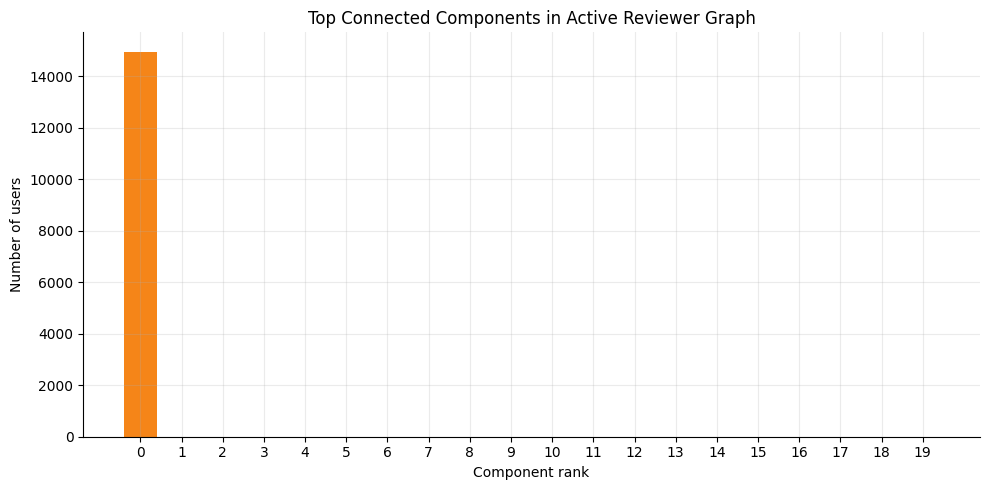

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\sna\top_component_sizes.png


In [8]:
component_sizes = [len(c) for c in components[:20]]
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([str(i) for i in range(len(component_sizes))], component_sizes, color="#F58518")
ax.set_title("Top Connected Components in Active Reviewer Graph")
ax.set_xlabel("Component rank")
ax.set_ylabel("Number of users")
fig.tight_layout()
path = FIGURES_DIR / "top_component_sizes.png"
fig.savefig(path, dpi=160)
plt.show()
plt.close(fig)
print(path)

## Interpretation

The resulting network features are simple and feasible at the dataset scale. Degree and PageRank capture social position, component size captures whether a user belongs to a larger connected structure, and the community label gives a coarse group assignment for users in the largest connected component.

These user-level features will be aggregated to the business-month level in the next notebook.